# Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mode

#scaling numerical data
from sklearn.preprocessing import MinMaxScaler

# mutual information library
# as the target column is sale price and it is continuous we use mutual_info_regression
from sklearn.feature_selection import mutual_info_regression

#encoding non numerical columns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# for train test split we have to import the method from scikit learn
from sklearn.model_selection import train_test_split

# for linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# for evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score



# Dataset Overview

In [2]:
# Loading dataset

filepath = '/content/drive/MyDrive/Colab Notebooks/Datasets /House_Pricing.csv'
df_hprice = pd.read_csv(filepath)
df_hprice.head(3)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062


In [3]:
df_hprice.head(3)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062


#EDA

In [4]:
df_hprice.shape

(21613, 21)

In [5]:
df_hprice.size

453873

In [6]:
# Displaying basic information

In [7]:
df_hprice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [8]:
df_hprice.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Duplicate Handling

In [9]:
df_hprice.duplicated().sum()  # No duplicate values to remove

np.int64(0)

## Null Value Handling

In [10]:
# Checking null values in each column
# Before removing column
df_hprice.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [11]:
df_hprice = df_hprice.drop(columns = ["No of Times Visited"], axis = 1)

# 'N.o of Times Visited' contain large number of null values, therefore that column is removed

In [12]:
#After removing the column "No of times visited"
df_hprice.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [13]:
# Before removing corresponding row of target column where the  value is null

df_hprice.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [14]:
# Dropping rows

df_hprice = df_hprice.dropna(subset = ["Sale Price"])


In [15]:
# After removing corresponding row of target column where the  value is null

df_hprice.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


##Histogram

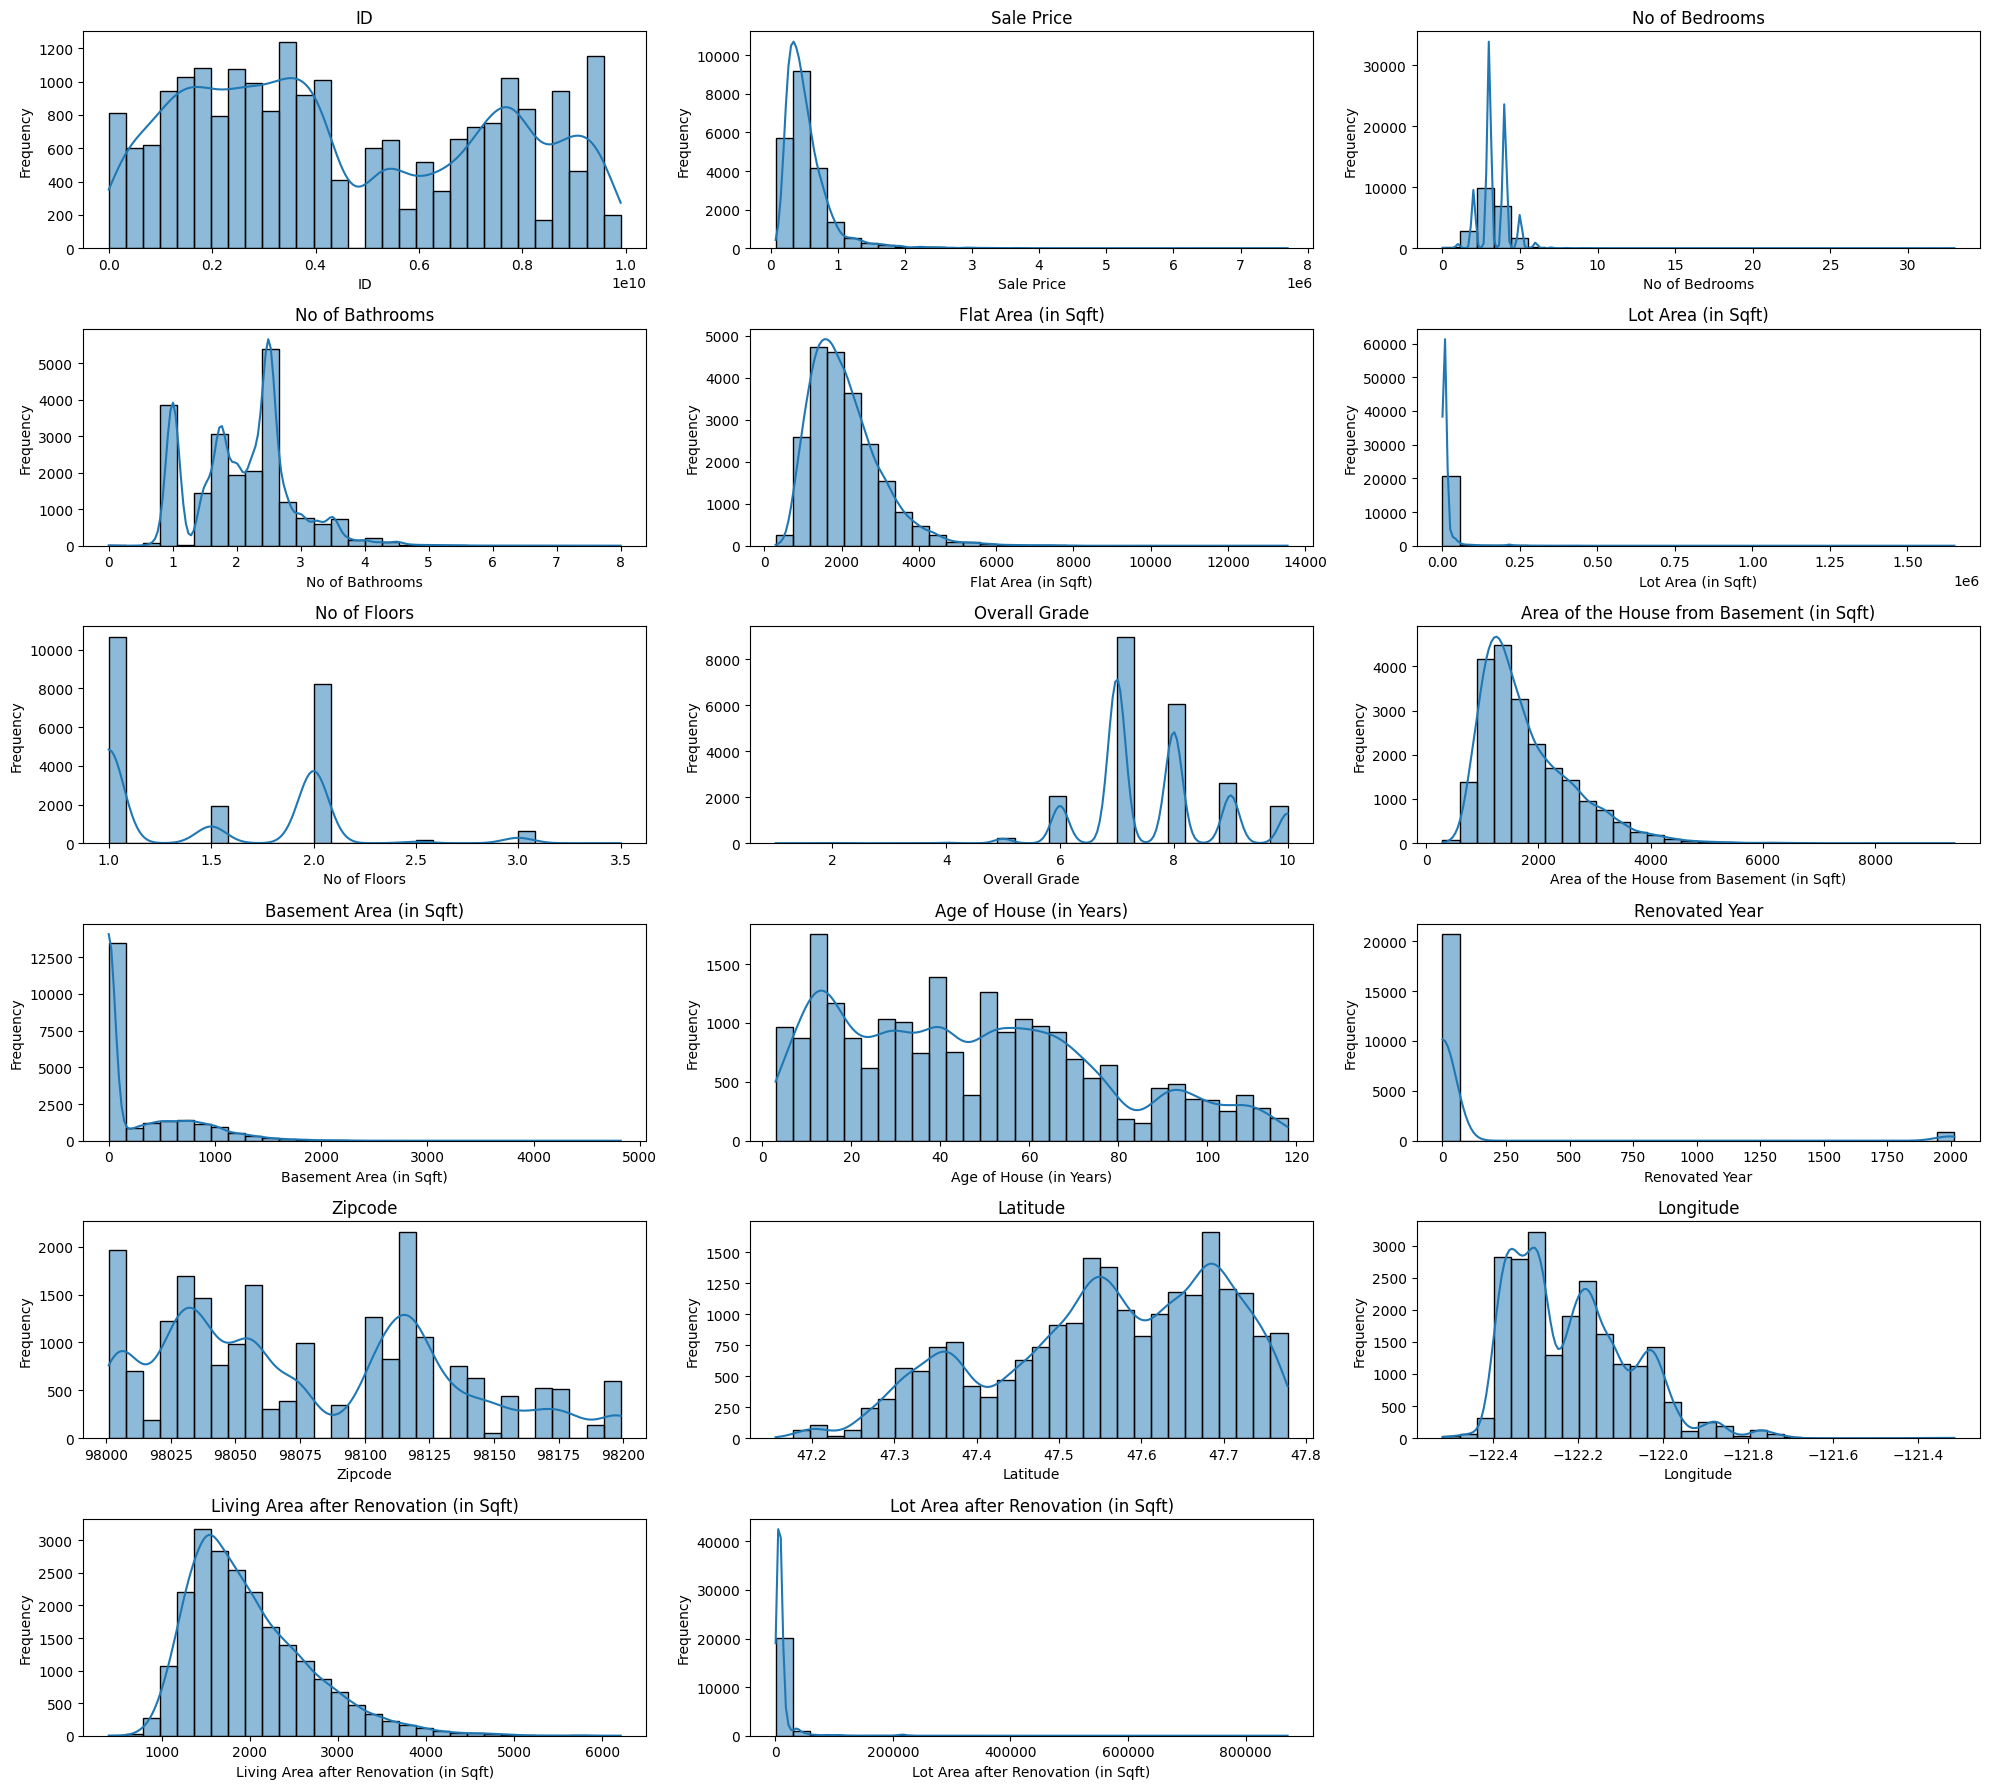

In [16]:
# Plotting histogram for missing values

num_columns = df_hprice.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 18))

for i, col in enumerate(num_columns, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df_hprice[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Filling Missing Values

In [17]:
# Before handling missing values

df_hprice.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [18]:
# N.o of bathroom columns are categorical column, therefore using mode to fill missing value

df_hprice['No of Bathrooms'].fillna(mode(df_hprice['No of Bathrooms']), inplace=True)

# the below columns are numerical and the data distribution is skewed

df_hprice['Flat Area (in Sqft)'].fillna(df_hprice['Flat Area (in Sqft)'].median(), inplace=True)

df_hprice['Lot Area (in Sqft)'].fillna(df_hprice['Lot Area (in Sqft)'].median(), inplace=True)

df_hprice['Area of the House from Basement (in Sqft)'].fillna(df_hprice['Area of the House from Basement (in Sqft)'].median(), inplace=True)

df_hprice['Living Area after Renovation (in Sqft)'].fillna(df_hprice['Living Area after Renovation (in Sqft)'].median(), inplace=True)


/tmp/ipykernel_483/2750659900.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hprice['No of Bathrooms'].fillna(mode(df_hprice['No of Bathrooms']), inplace=True)
/tmp/ipykernel_483/2750659900.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [19]:
# Latitude, Longitude and Zipcode are unique values and can't be handled
# Since the missing values of these are negligible, corresponding rows are removed

df_hprice.dropna(subset=['Zipcode', 'Latitude', 'Longitude'], inplace=True, axis=0)


In [20]:
# After handling missing values

df_hprice.isnull().sum()


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [21]:
# Fixing Target and Feature Columns
# Target column: Sales price
y = df_hprice['Sale Price']

# expect the Sales price all others are feature columns
X = df_hprice.drop(columns=['Sale Price'])


## Feature Engineering

In [22]:
num_cols = X.select_dtypes(include=['int64','float64']).columns    # Numerical columns of feature
cat_cols = X.select_dtypes(include=['object']).columns             # Categorical columns of features

print(num_cols)
print(cat_cols)

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [23]:
X.nunique()

,0
ID,21429
Date House was Sold,13
No of Bedrooms,13
No of Bathrooms,30
Flat Area (in Sqft),1036
Lot Area (in Sqft),9778
No of Floors,6
Waterfront View,2
Condition of the House,5
Overall Grade,10


In [24]:
X_num_cols = X.drop(columns=['ID','No of Bedrooms', 'No of Bathrooms', 'No of Floors', 'Overall Grade', 'Zipcode','Waterfront View', 'Condition of the House', 'Date House was Sold'])
X_num_cols


,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,1180.0,5650.0,1180.0,0,63,0,47.5112,-122.257,1340.0,5650
1,2570.0,7242.0,2170.0,400,67,1991,47.7210,-122.319,1690.0,7639
2,770.0,10000.0,770.0,0,85,0,47.7379,-122.233,2720.0,8062
3,1960.0,5000.0,1050.0,910,53,0,47.5208,-122.393,1360.0,5000
4,1680.0,8080.0,1680.0,0,31,0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...
21608,1530.0,1131.0,1530.0,0,9,0,47.6993,-122.346,1530.0,1509
21609,2310.0,5813.0,2310.0,0,4,0,47.5107,-122.362,1830.0,7200
21610,1020.0,1350.0,1020.0,0,9,0,47.5944,-122.299,1020.0,2007
21611,1600.0,2388.0,1600.0,0,14,0,47.5345,-122.069,1410.0,1287


In [25]:
#Splitting the column date format

X[['day', 'month', 'year']] = X['Date House was Sold'].str.split(' ', expand = True) # Splitting the date format column
X.head(3)

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,14 October 2017,3,1.00,1180.0,5650.0,1.0,No,Fair,7,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,14,October,2017
1,6414100192,14 December 2017,3,2.25,2570.0,7242.0,2.0,No,Fair,7,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,14,December,2017
2,5631500400,15 February 2016,2,1.00,770.0,10000.0,1.0,No,Fair,6,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,15,February,2016


In [26]:
# After splitting the original date column is dropped

X.drop(columns = ['Date House was Sold'], inplace = True)
X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,14,October,2017
1,6414100192,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,14,December,2017
2,5631500400,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,15,February,2016


# Scaling

In [27]:
X_num_cols.head(5)

,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,1180.0,5650.0,1180.0,0,63,0,47.5112,-122.257,1340.0,5650
1,2570.0,7242.0,2170.0,400,67,1991,47.7210,-122.319,1690.0,7639
2,770.0,10000.0,770.0,0,85,0,47.7379,-122.233,2720.0,8062
3,1960.0,5000.0,1050.0,910,53,0,47.5208,-122.393,1360.0,5000
4,1680.0,8080.0,1680.0,0,31,0,47.6168,-122.045,1800.0,7503


In [28]:
# Scaling the numerical columns of feature column
# Since all are skewed, use normalization ( MinMax Scaling )

min_max_scaler = MinMaxScaler()
skewed_cols = ['year', 'day', 'Flat Area (in Sqft)',	'Lot Area (in Sqft)',	'Area of the House from Basement (in Sqft)',	'Basement Area (in Sqft)',	'Age of House (in Years)',	'Renovated Year',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)',	'Lot Area after Renovation (in Sqft)']

X[skewed_cols] = min_max_scaler.fit_transform(X[skewed_cols])

In [29]:
X.head(5)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,0.083333,...,0.434783,0.000000,98136.0,0.586939,0.104651,0.165376,0.004996,0.0,December,1.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,No,Fair,8,0.152412,...,0.243478,0.000000,98074.0,0.741354,0.393688,0.241094,0.007871,1.0,February,0.0


# Encoding

In [30]:
print(X.select_dtypes(include='object').columns)


Index(['Waterfront View', 'Condition of the House', 'month'], dtype='object')


In [31]:
X['month'].unique()

array(['October', 'December', 'February', 'May', 'June', 'January',
       'April', 'March', 'July', 'August', 'November', 'September'],
      dtype=object)

In [32]:
X['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [33]:
X['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

##Label Encoding

In [34]:
# Before Label Encoding

X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


In [35]:
L_encode = LabelEncoder()
X['Waterfront View'] = L_encode.fit_transform(X['Waterfront View'])

In [36]:
# After Label encoding

X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


##One Hot Encoding

In [37]:
# Before encoding

X.head(3)

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),day,month,year
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,Fair,7,0.097588,...,0.521739,0.000000,98178.0,0.571498,0.217608,0.161934,0.005742,0.0,October,1.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,Fair,7,0.206140,...,0.556522,0.988089,98125.0,0.908959,0.166113,0.222165,0.008027,0.0,December,1.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,Fair,6,0.052632,...,0.713043,0.000000,98028.0,0.936143,0.237542,0.399415,0.008513,1.0,February,0.0


In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21606 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21606 non-null  int64  
 1   No of Bedrooms                             21606 non-null  int64  
 2   No of Bathrooms                            21606 non-null  float64
 3   Flat Area (in Sqft)                        21606 non-null  float64
 4   Lot Area (in Sqft)                         21606 non-null  float64
 5   No of Floors                               21606 non-null  float64
 6   Waterfront View                            21606 non-null  int64  
 7   Condition of the House                     21606 non-null  object 
 8   Overall Grade                              21606 non-null  int64  
 9   Area of the House from Basement (in Sqft)  21606 non-null  float64
 10  Basement Area (in Sqft)    

In [39]:
OHE_obj = OneHotEncoder(sparse_output=False)
ohe_cols = ['Condition of the House', 'month']

encoded_data = OHE_obj.fit_transform(X[ohe_cols])
encoded_cols = OHE_obj.get_feature_names_out(ohe_cols)

encoded_X = pd.DataFrame(encoded_data, columns = encoded_cols, index = X.index)
encoded_X.head(3)



,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay,month_April,month_August,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# Concatenating the encode columns with 'X' and dropping the original columns

X = pd.concat([X.drop(columns = ohe_cols), encoded_X], axis = 1)
X.head(10)


,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,7129300520,3,1.00,0.067170,0.003108,1.0,0,7,0.097588,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6414100192,3,2.25,0.172075,0.004072,2.0,0,7,0.206140,0.082988,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,2,1.00,0.036226,0.005743,1.0,0,6,0.052632,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,4,3.00,0.126038,0.002714,1.0,0,7,0.083333,0.188797,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,3,2.00,0.104906,0.004579,1.0,0,8,0.152412,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,7237550310,4,4.50,0.387170,0.061429,1.0,0,10,0.394737,0.317427,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,1321400060,3,2.25,0.107547,0.003816,2.0,0,7,0.156250,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,2008000270,3,1.50,0.058113,0.005567,1.0,0,7,0.084430,0.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2414600126,3,1.00,0.112453,0.004210,1.0,0,7,0.083333,0.151452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,3793500160,3,2.50,0.120755,0.003659,2.0,0,7,0.175439,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [41]:
# After Encoding

X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 21606 entries, 0 to 21612
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21606 non-null  int64  
 1   No of Bedrooms                             21606 non-null  int64  
 2   No of Bathrooms                            21606 non-null  float64
 3   Flat Area (in Sqft)                        21606 non-null  float64
 4   Lot Area (in Sqft)                         21606 non-null  float64
 5   No of Floors                               21606 non-null  float64
 6   Waterfront View                            21606 non-null  int64  
 7   Overall Grade                              21606 non-null  int64  
 8   Area of the House from Basement (in Sqft)  21606 non-null  float64
 9   Basement Area (in Sqft)                    21606 non-null  float64
 10  Age of House (in Years)    

#Mutual Information

In [42]:
X.drop(columns = ['Zipcode', 'Latitude','Longitude','ID'], inplace = True)

In [43]:
# mutual information of each column in 'X_encode' with respect to 'y'

mi = mutual_info_regression(X, y)

# converting into a dataframe
mi_X = pd.DataFrame({'Features' : X.columns, 'mutual Information':mi})
mi_X


,Features,mutual Information
0,No of Bedrooms,0.084526
1,No of Bathrooms,0.204375
2,Flat Area (in Sqft),0.352047
3,Lot Area (in Sqft),0.059986
4,No of Floors,0.076194
5,Waterfront View,0.007632
6,Overall Grade,0.342769
7,Area of the House from Basement (in Sqft),0.261642
8,Basement Area (in Sqft),0.065743
9,Age of House (in Years),0.073822


In [44]:
selected_features = mi_X[mi_X['mutual Information'] > 0.01]
selected_features

,Features,mutual Information
0,No of Bedrooms,0.084526
1,No of Bathrooms,0.204375
2,Flat Area (in Sqft),0.352047
3,Lot Area (in Sqft),0.059986
4,No of Floors,0.076194
6,Overall Grade,0.342769
7,Area of the House from Basement (in Sqft),0.261642
8,Basement Area (in Sqft),0.065743
9,Age of House (in Years),0.073822
10,Renovated Year,0.015675


In [45]:
X = X[selected_features['Features'].tolist()]
X

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,3,1.00,0.067170,0.003108,1.0,7,0.097588,0.000000,0.521739,0.000000,0.161934,0.005742
1,3,2.25,0.172075,0.004072,2.0,7,0.206140,0.082988,0.556522,0.988089,0.222165,0.008027
2,2,1.00,0.036226,0.005743,1.0,6,0.052632,0.000000,0.713043,0.000000,0.399415,0.008513
3,4,3.00,0.126038,0.002714,1.0,7,0.083333,0.188797,0.434783,0.000000,0.165376,0.004996
4,3,2.00,0.104906,0.004579,1.0,8,0.152412,0.000000,0.243478,0.000000,0.241094,0.007871
...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,0.093585,0.000370,3.0,8,0.135965,0.000000,0.052174,0.000000,0.194631,0.000986
21609,4,2.50,0.152453,0.003206,2.0,8,0.221491,0.000000,0.008696,0.000000,0.246257,0.007523
21610,2,0.75,0.055094,0.000503,2.0,7,0.080044,0.000000,0.052174,0.000000,0.106866,0.001558
21611,3,2.50,0.098868,0.001132,2.0,8,0.143640,0.000000,0.095652,0.000000,0.173980,0.000731


# Outlier Handling

##Boxplot

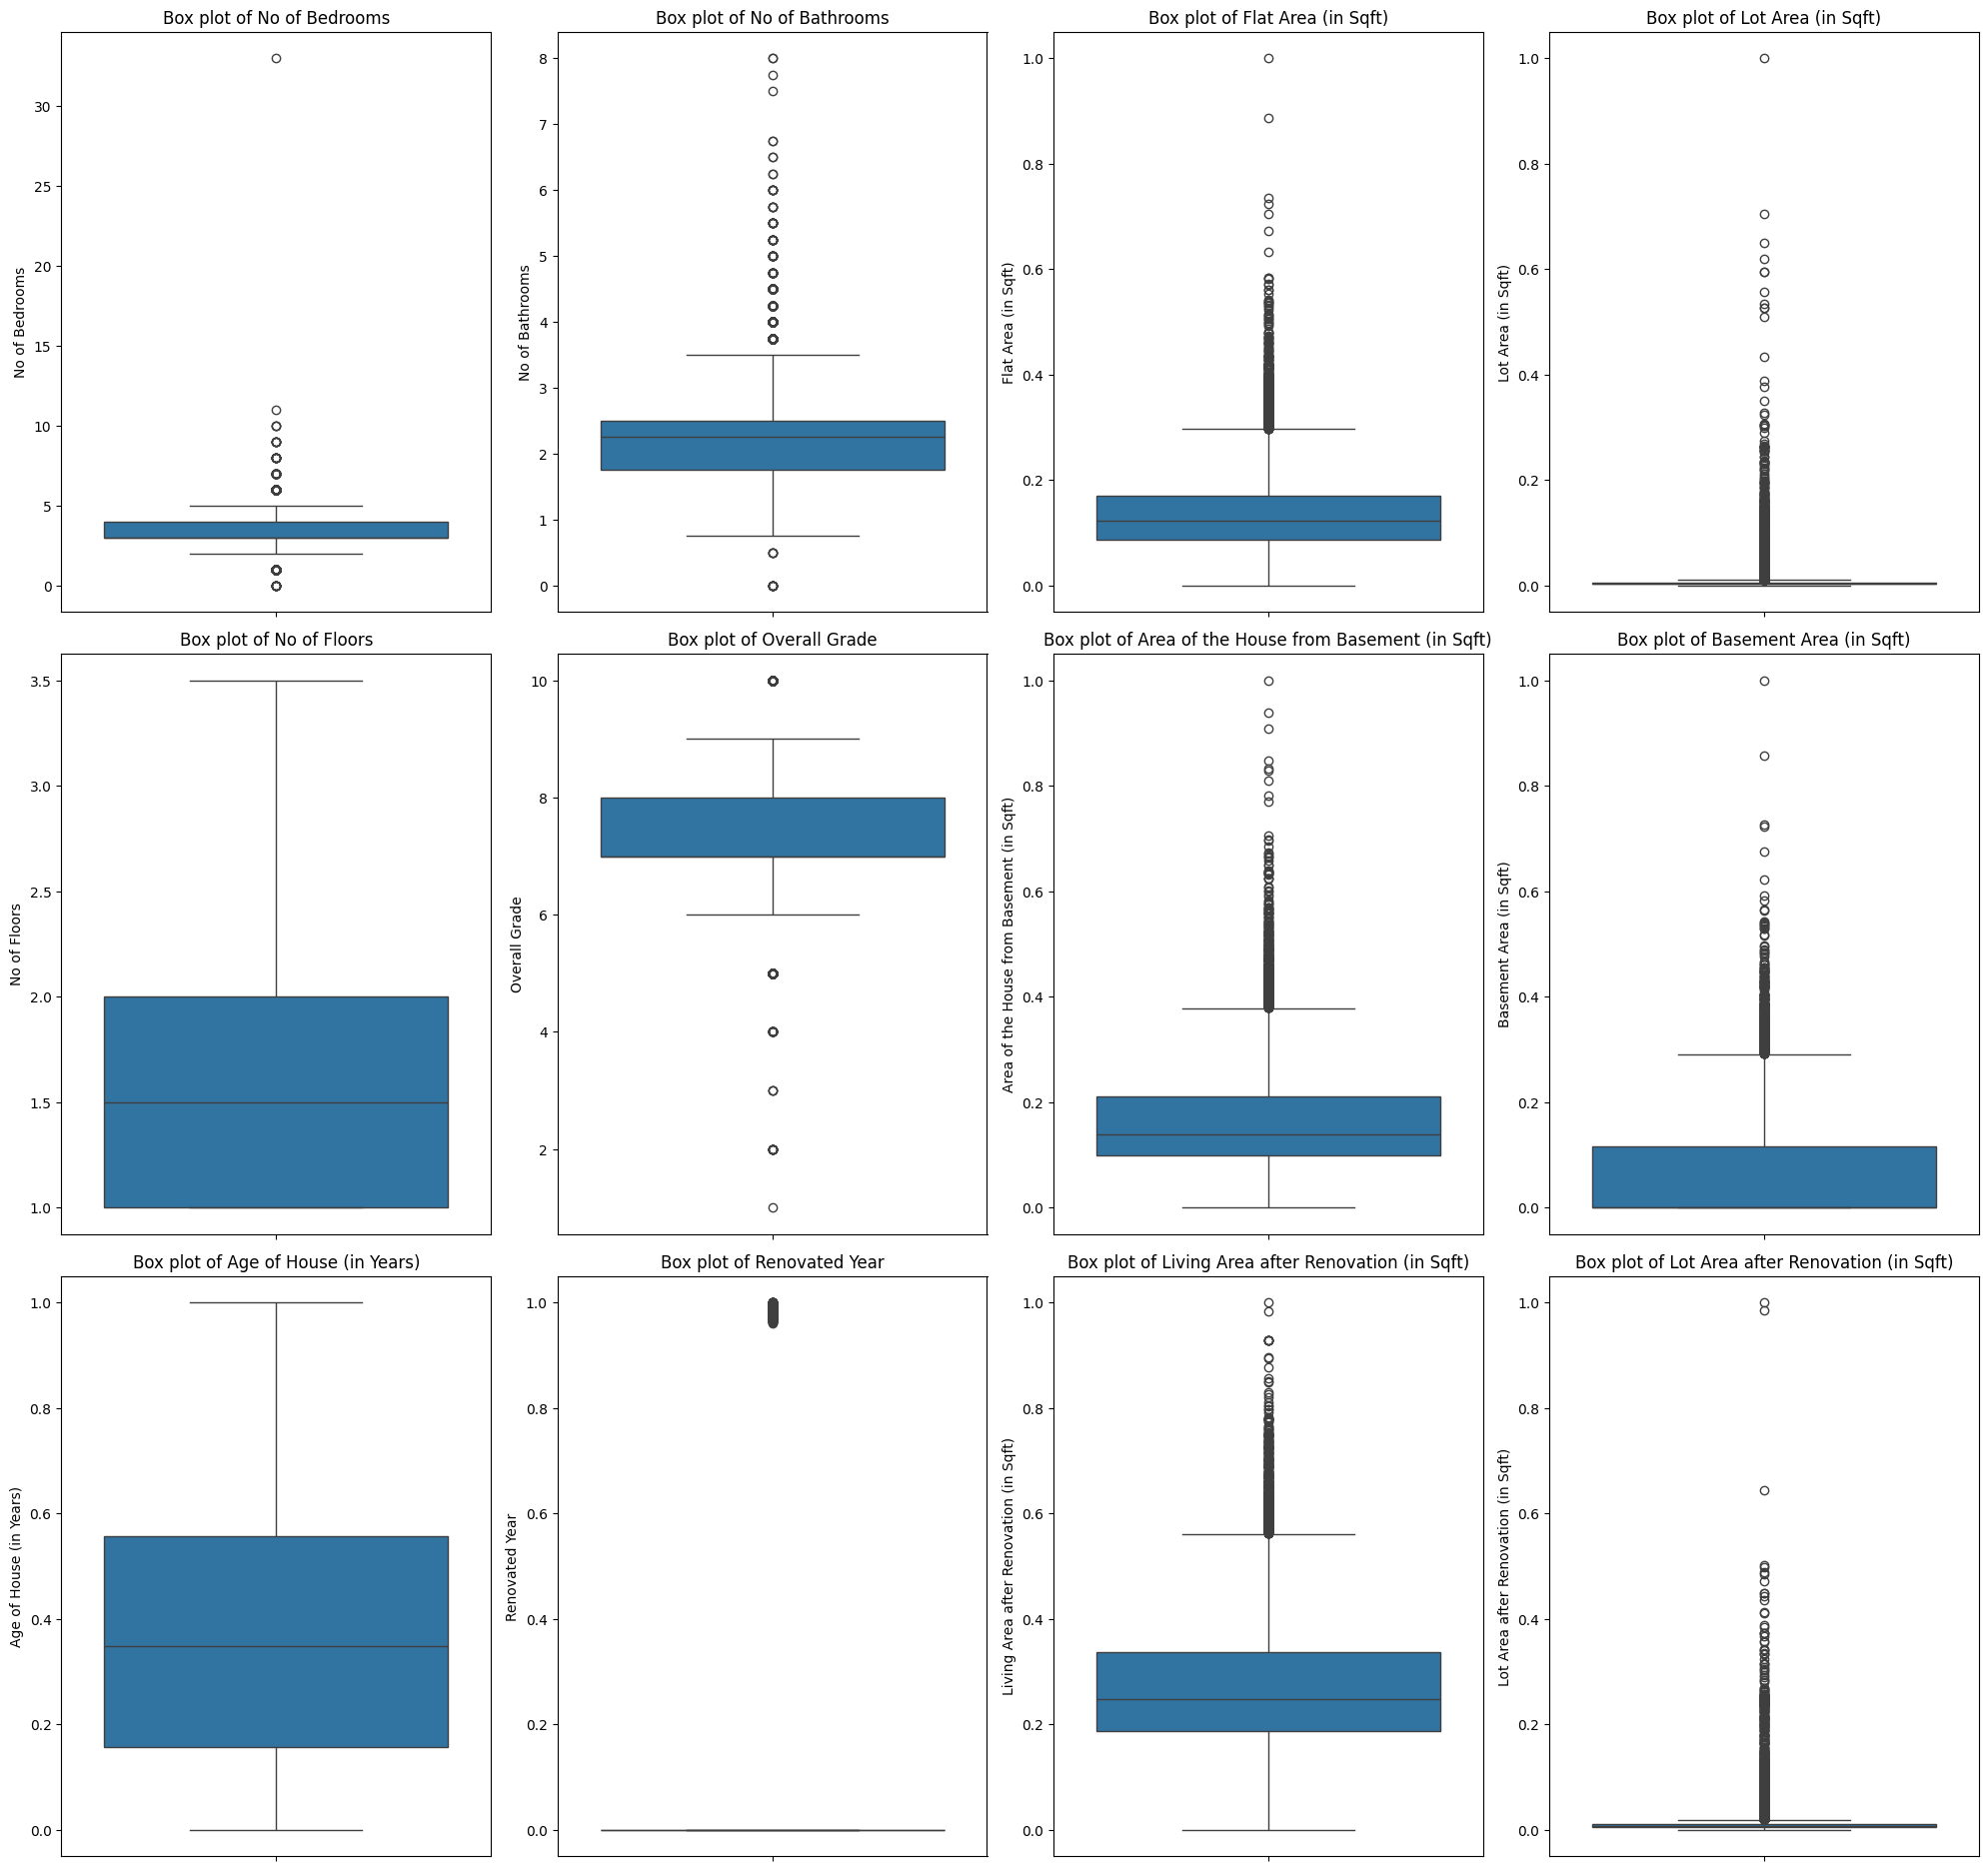

In [46]:
plt.figure(figsize = (20,25))

for i, column in enumerate(X.columns,1):
  plt.subplot(4,4,i)
  plt.title(f'Box plot of {column}')
  sns.boxplot( X[column])
plt.tight_layout()
plt.show()

# Boxplots before handling outliers

## Handling Outliers

In [47]:
def clipping(column):
  Q1 = X[column].quantile(0.25)
  Q3 = X[column].quantile(0.75)
  IQR = Q3 - Q1

  upper_bound = Q1 - (1.5 * IQR)
  lower_bound = Q3 + (1.5 * IQR)

  X[column] = np.clip(X[column], lower_bound, upper_bound)
  return X


# Applying clipping to all columns

for column in X.columns:
  X = clipping(column)

In [48]:
X.head(5)

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,3.0,1.00,0.067170,0.003108,1.0,7.0,0.097588,0.000000,0.521739,0.0,0.161934,0.005742
1,3.0,2.25,0.172075,0.004072,2.0,7.0,0.206140,0.082988,0.556522,0.0,0.222165,0.008027
2,2.0,1.00,0.036226,0.005743,1.0,6.0,0.052632,0.000000,0.713043,0.0,0.399415,0.008513
3,4.0,3.00,0.126038,0.002714,1.0,7.0,0.083333,0.188797,0.434783,0.0,0.165376,0.004996
4,3.0,2.00,0.104906,0.004579,1.0,8.0,0.152412,0.000000,0.243478,0.0,0.241094,0.007871


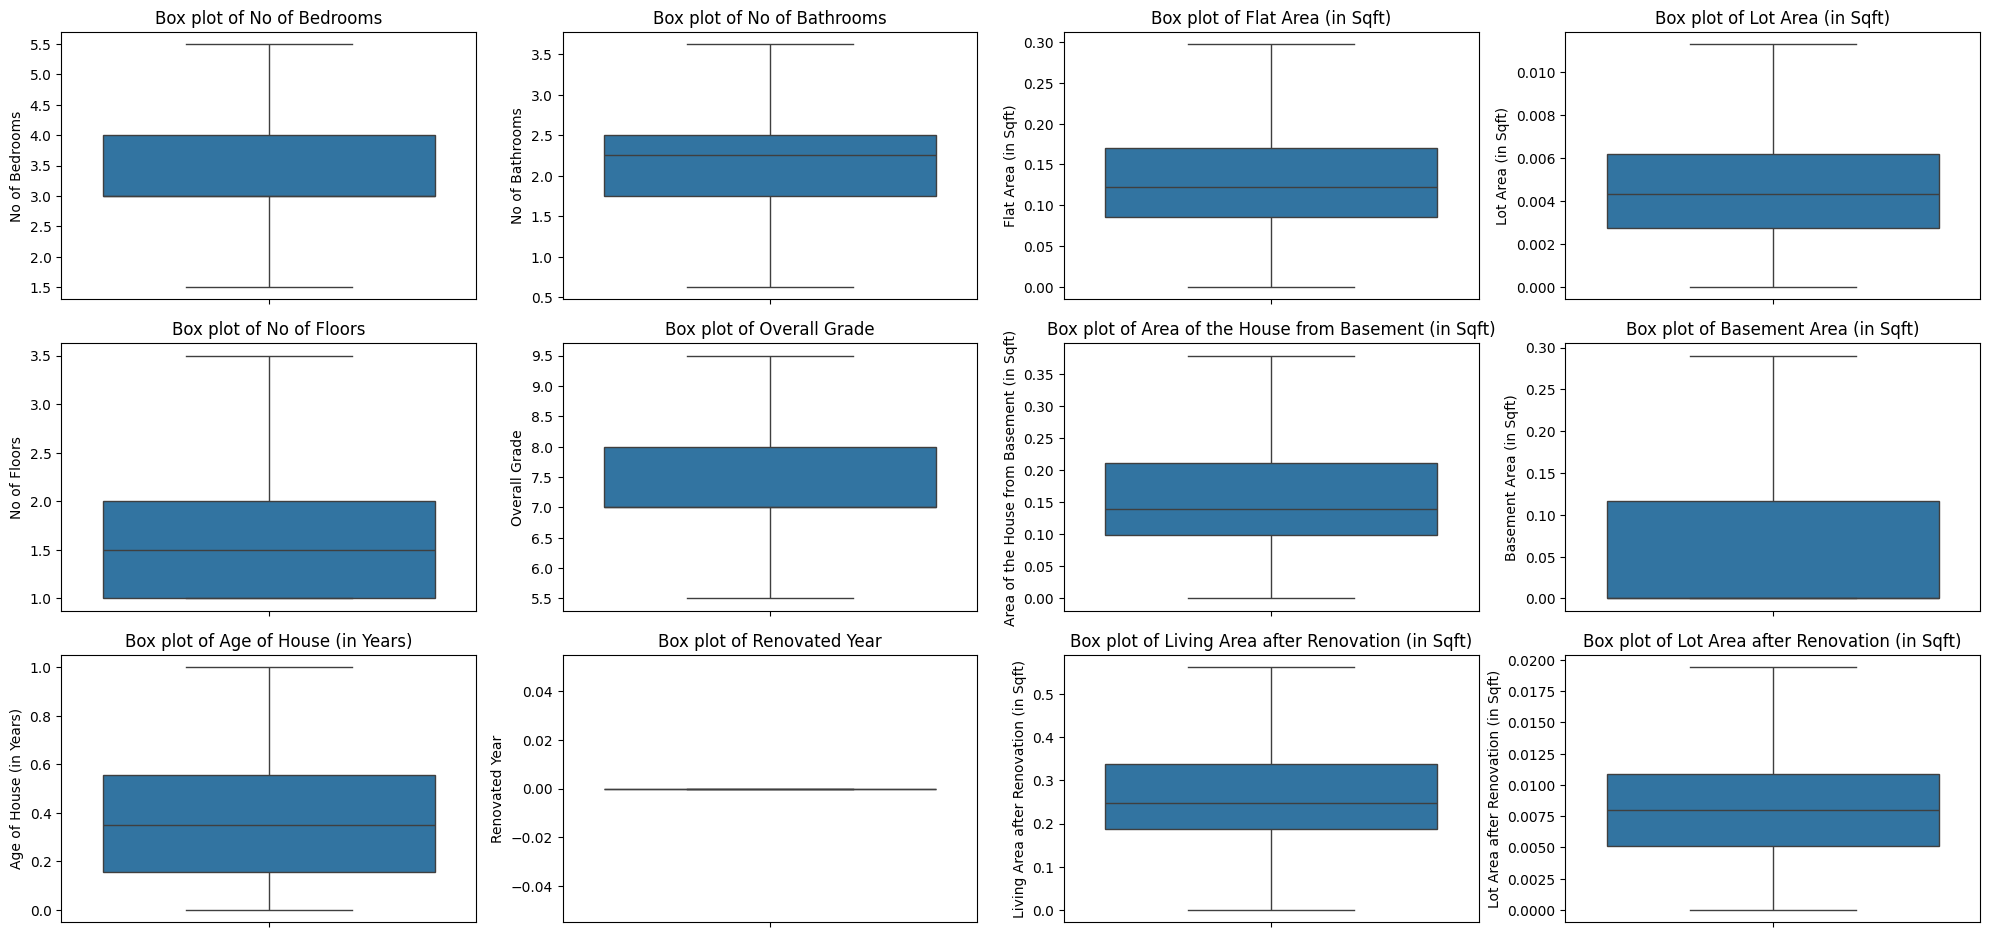

In [49]:
# Boxplot after outlier handlings

plt.figure(figsize = (20,25))

for i, column in enumerate(X.columns):
  plt.subplot(8,4,i+1)
  plt.title(f'Box plot of {column}')
  sns.boxplot(y = X[column])
plt.tight_layout()
plt.show()

In [50]:
y.skew()

np.float64(4.021235534919448)

In [51]:
y = np.log1p(y) # Transforming sale price

In [52]:
# Split already done

In [53]:
# Splitting data into target and features

X.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,3.0,1.00,0.067170,0.003108,1.0,7.0,0.097588,0.000000,0.521739,0.0,0.161934,0.005742
1,3.0,2.25,0.172075,0.004072,2.0,7.0,0.206140,0.082988,0.556522,0.0,0.222165,0.008027
2,2.0,1.00,0.036226,0.005743,1.0,6.0,0.052632,0.000000,0.713043,0.0,0.399415,0.008513
3,4.0,3.00,0.126038,0.002714,1.0,7.0,0.083333,0.188797,0.434783,0.0,0.165376,0.004996
4,3.0,2.00,0.104906,0.004579,1.0,8.0,0.152412,0.000000,0.243478,0.0,0.241094,0.007871


In [54]:
y.head()

,Sale Price
0,12.309987
1,13.195616
2,12.100718
3,13.311331
4,13.142168


#Train Test Split

In [55]:
# Splitting data into train and test data

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)    # test_size indicate 0.2 means 20% of data, random_state used for random shuffiing logic

## Model Building

In [56]:
X.dtypes

,0
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,float64
Area of the House from Basement (in Sqft),float64
Basement Area (in Sqft),float64
Age of House (in Years),float64
Renovated Year,float64


####Linear Regressor

In [57]:
#Linear regression

# create model object
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

# predictions using the model
y_pred = lin_reg.predict(X_test)

# evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2 )




MAE: 0.2503802244622472
MSE: 0.10272445613731741
RMSE: 0.3205065617695173
R2: 0.6320675442113767


####KNN Regressor

In [58]:
#KNN regression

# create model object
knn_reg = KNeighborsRegressor()

# Train the model
knn_reg.fit(X_train, y_train)

# predictions using the model
y_pred = knn_reg.predict(X_test)

# evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2 )




MAE: 0.2530342186043635
MSE: 0.10504578083578793
RMSE: 0.32410766858528345
R2: 0.623753159019117


####Decision Tree

In [59]:
#Decision regression

# create model object
dec_reg = DecisionTreeRegressor()

# Train the model
dec_reg.fit(X_train, y_train)

# predictions using the model
y_pred = dec_reg.predict(X_test)

# evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2 )




MAE: 0.3015102876168306
MSE: 0.1589306938760558
RMSE: 0.3986611266176523
R2: 0.4307513254697657


####RandomForest

In [60]:
#Random Forest regression

# create model object
Random_reg = RandomForestRegressor()

# Train the model
Random_reg.fit(X_train, y_train)

# predictions using the model
y_pred = Random_reg.predict(X_test)

# evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2 )




MAE: 0.21967183440993446
MSE: 0.08182118273015757
RMSE: 0.28604402236396687
R2: 0.7069376677235069


##